<a href="https://colab.research.google.com/github/UAMCAntwerpen/2040FBDBIC/blob/main/07_QSAR_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install RDKit

In [ ]:
import sys
import os
import requests
import subprocess
import shutil
from logging import getLogger, StreamHandler, INFO

logger = getLogger(__name__)
logger.addHandler(StreamHandler())
logger.setLevel(INFO)

def install(
        chunk_size=4096,
        file_name="Miniconda3-latest-Linux-x86_64.sh",
        url_base="https://repo.continuum.io/miniconda/",
        conda_path=os.path.expanduser(os.path.join("~", "miniconda")),
        rdkit_version=None,
        add_python_path=True,
        force=False):

    python_path = os.path.join(
        conda_path,
        "lib",
        "python{0}.{1}".format(*sys.version_info),
        "site-packages",
    )

    if add_python_path and python_path not in sys.path:
        logger.info("add {} to PYTHONPATH".format(python_path))
        sys.path.append(python_path)

    if os.path.isdir(os.path.join(python_path, "rdkit")):
        logger.info("rdkit is already installed")
        if not force:
            return

        logger.info("force re-install")

    url = url_base + file_name
    python_version = "{0}.{1}.{2}".format(*sys.version_info)

    logger.info("python version: {}".format(python_version))

    if os.path.isdir(conda_path):
        logger.warning("remove current miniconda")
        shutil.rmtree(conda_path)
    elif os.path.isfile(conda_path):
        logger.warning("remove {}".format(conda_path))
        os.remove(conda_path)

    logger.info('fetching installer from {}'.format(url))
    res = requests.get(url, stream=True)
    res.raise_for_status()
    with open(file_name, 'wb') as f:
        for chunk in res.iter_content(chunk_size):
            f.write(chunk)
    logger.info('done')

    logger.info('installing miniconda to {}'.format(conda_path))
    subprocess.check_call(["bash", file_name, "-b", "-p", conda_path])
    logger.info('done')

    logger.info("installing rdkit")
    subprocess.check_call([
        os.path.join(conda_path, "bin", "conda"),
        "install",
        "--yes",
        "-c", "rdkit",
        "python=={}".format(python_version),
        "rdkit" if rdkit_version is None else "rdkit=={}".format(rdkit_version)])
    logger.info("done")

    import rdkit
    logger.info("rdkit-{} installation finished!".format(rdkit.__version__))


install()

rdkit is already installed
rdkit is already installed


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

## Validation

#### Performance metrics

In [ ]:
# Real data
real = np.array([1,1,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,1])

# Predictions from a good model
good = np.array([1,0,1,1,0,1,1,0,1,0,1,0,1,0,0,0,1,0,1,1])

# Predictions from a bad model
bad = np.array([0,0,0,0,1,1,0,1,0,1,0,1,0,0,1,1,0,1,0,0])

# Predictions from a random model
random = np.random.randint(2, size=20)

print("Real  ", real)
print("Good  ", good)
print("Bad   ", bad)
print("Random", random)

Real   [1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 1]
Good   [1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1]
Bad    [0 0 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 0 0]
Random [0 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 0]


In [ ]:
# Function to calculate number of true positives
def TP(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 1 and pred[i] == 1: n += 1
  return float(n)

In [ ]:
# Function to calculate number of false positives
def FP(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 0 and pred[i] == 1: n += 1
  return float(n)

In [ ]:
# Function to calculate number of true negatives
def TN(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 0 and pred[i] == 0: n += 1
  return float(n)

In [ ]:
# Function to calculate number of false negatives
def FN(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 1 and pred[i] == 0: n += 1
  return float(n)

In [ ]:
# Apply metrics onto the three models

# 1. Good model
print("Good model")
print("TP", TP(real, good))
print("TN", TN(real, good))
print("FP", FP(real, good))
print("FN", FN(real, good))

# 2. Bad model
print("Bad model")
print("TP", TP(real, bad))
print("TN", TN(real, bad))
print("FP", FP(real, bad))
print("FN", FN(real, bad))

# 3. Random model
print("Random model")
print("TP", TP(real, random))
print("TN", TN(real, random))
print("FP", FP(real, random))
print("FN", FN(real, random))

Good model
TP 10.0
TN 7.0
FP 1.0
FN 2.0
Bad model
TP 0.0
TN 0.0
FP 8.0
FN 12.0
Random model
TP 5.0
TN 5.0
FP 3.0
FN 7.0


In [ ]:
# Rates
def TPR(real, pred):
  tp = TP(real, pred)
  fn = FN(real, pred)
  return tp / (tp + fn)

def TNR(real, pred):
  tn = TN(real, pred)
  fp = FP(real, pred)
  return tn / (tn + fp)

def FPR(real, pred):
  fp = FP(real, pred)
  tn = TN(real, pred)
  return fp / (fp + tn)

def FNR(real, pred):
  fn = FN(real, pred)
  tp = TP(real, pred)
  return fn / (fn + tp)

In [ ]:
# Apply metrics onto the three models

# 1. Good model
print("Good model")
print("TPR", TPR(real, good))
print("TNR", TNR(real, good))
print("FPR", FPR(real, good))
print("FNR", FNR(real, good))

# 2. Bad model
print("Bad model")
print("TPR", TPR(real, bad))
print("TNR", TNR(real, bad))
print("FPR", FPR(real, bad))
print("FNR", FNR(real, bad))

# 3. Random model
print("Random model")
print("TPR", TPR(real, random))
print("TNR", TNR(real, random))
print("FPR", FPR(real, random))
print("FNR", FNR(real, random))

Good model
TPR 0.8333333333333334
TNR 0.875
FPR 0.125
FNR 0.16666666666666666
Bad model
TPR 0.0
TNR 0.0
FPR 1.0
FNR 1.0
Random model
TPR 0.4166666666666667
TNR 0.625
FPR 0.375
FNR 0.5833333333333334


Text(0, 0.5, 'Number of FN (blue) and TP (red)')

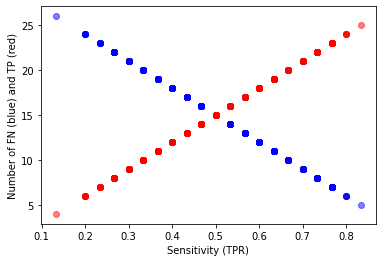

In [ ]:
# Trade-off between sensitivity (TPR), number of false negatives (FN) and true positives (TP)
import matplotlib.pyplot as plt

real = np.array([0,1]*30)

sensitivities = []
true_positives = []
false_negatives = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  sensitivities.append(TPR(real, model))
  false_negatives.append(FN(real, model))
  true_positives.append(TP(real, model))
plt.scatter(sensitivities, false_negatives, c="blue", alpha=0.5)
plt.scatter(sensitivities, true_positives, c="red", alpha=0.5)
plt.xlabel("Sensitivity (TPR)")
plt.ylabel("Number of FN (blue) and TP (red)")

Text(0, 0.5, 'Number of FP (blue) and TN (red)')

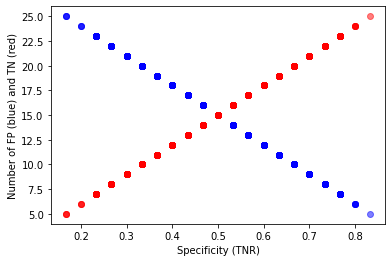

In [ ]:
# Relation between specificity (TNR), number of false positives (FP) and true negatives (TN)
real = np.array([0,1]*30)

specificities = []
false_positives = []
true_negatives = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  specificities.append(TNR(real,model))
  false_positives.append(FP(real,model))
  true_negatives.append(TN(real,model))
plt.scatter(specificities, false_positives, c="blue", alpha=0.5)
plt.scatter(specificities, true_negatives, c="red", alpha=0.5)
plt.xlabel("Specificity (TNR)")
plt.ylabel("Number of FP (blue) and TN (red)")

Text(0, 0.5, 'Precision (blue) and sensitivity (red)')

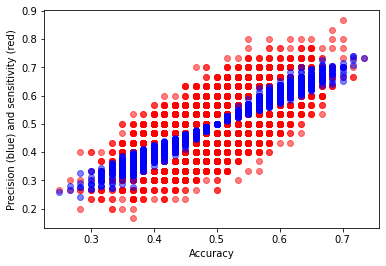

In [ ]:
# Relation between accuracy, precision and sensitivity
real = np.array([0,1]*30)

P = []
A = []
S = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  tp = TP(real,model)
  fp = FP(real,model)
  tn = TN(real,model)
  fn = FN(real,model)
  precision = (tp / (tp + fp))
  accuracy = (tp + tn) / (tp + fp + fn + tn)
  sensitivity = tp / (tp + fn)
  P.append(precision)
  A.append(accuracy)
  S.append(sensitivity)
plt.scatter(A, S, c="red", alpha=0.5)
plt.scatter(A, P, c="blue", alpha=0.5)
plt.xlabel("Accuracy")
plt.ylabel("Precision (blue) and sensitivity (red)")

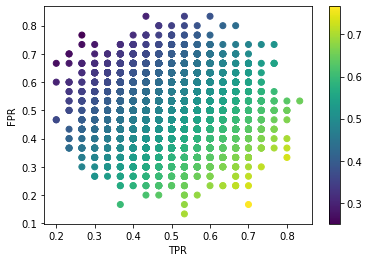

In [ ]:
# TPR and FPR: accuracy as a metric that balances high TPR and low FPR
real = np.array([0,1]*30)

TPRS = []
FPRS = []
ACCU = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  tp = TP(real,model)
  fp = FP(real,model)
  tn = TN(real,model)
  fn = FN(real,model)
  TPRS.append(tp / (tp + fn))
  FPRS.append(fp / (fp + tn))
  ACCU.append((tp + tn) / (tp + fp + fn + tn))
plt.scatter(TPRS, FPRS, c=ACCU)
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.colorbar()